In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

In [3]:
import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("jainpooja/fake-news-detection")
df0 = pd.read_csv(os.path.join(path, "Fake.csv"))
df1 = pd.read_csv(os.path.join(path, "True.csv"))

100%|██████████| 41.0M/41.0M [00:00<00:00, 50.1MB/s]


Extracting files...


In [4]:
df0.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
df1.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
df0["status"] = 0
df1["status"] = 1

In [7]:
df0.shape

(23481, 5)

In [8]:
df1.shape

(21417, 5)

In [9]:
df_merge = pd.concat([df0, df1], axis =0 )
df_merge.head(10)

,title,text,subject,date,status
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [10]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'status'], dtype='object')

In [11]:
df = df_merge.drop(["title", "subject","date"], axis = 1)

In [12]:
df.isnull().sum()

,0
text,0
status,0


In [13]:
df = df.sample(frac = 1)

In [14]:
df.reset_index(inplace = True)
df.drop(["index"], axis = 1, inplace = True)

In [15]:
df.columns

Index(['text', 'status'], dtype='object')

In [16]:
df.head()

,text,status
0,This has just got to end! We have kids pouring...,0
1,A new poll of New Hampshire voters could show ...,0
2,So many people want to call the Special Counse...,0
3,Just when you thought Muslims had cornered the...,0
4,SEOUL (Reuters) - North Korea s goal is reachi...,1


In [17]:
def wp(text):
    text = text.lower()
    text = re.sub('\\[.*?\\]', '', text)
    text = re.sub("\\W"," ",text)
    text = re.sub('https?:\\/\\/\\S+|www\\.\\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\\n', '', text)
    text = re.sub('\\w*\\d\\w*', '', text)
    return text

In [18]:
df["text"] = df["text"].apply(wp)

In [19]:
# Add 'status' column to df0 and df1
df0["status"] = 0
df1["status"] = 1

In [20]:
# Concatenate df0 and df1 into df_merge
df_merge = pd.concat([df0, df1], axis=0)
display(df_merge.head(10))

,title,text,subject,date,status
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [21]:
# Create df from df_merge by dropping irrelevant columns
df = df_merge.drop(["title", "subject", "date"], axis=1)

# Shuffle the DataFrame
df = df.sample(frac=1, random_state=42) # Added random_state for reproducibility

# Reset the index and drop the old index column
df.reset_index(inplace=True)
df.drop(["index"], axis=1, inplace=True)

# Apply the text preprocessing function
df["text"] = df["text"].apply(wp)

display(df.head())

,text,status
0,century wire says ben stein reputable profes...,0
1,washington reuters u s president donald t...,1
2,reuters puerto rico governor ricardo rosse...,1
3,on monday donald trump once again embarrassed...,0
4,glasgow scotland reuters most u s presid...,1


In [22]:
x = df["text"]
y = df["status"]

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25,random_state=42)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(xv_train,y_train)

LogisticRegression()

In [26]:
pred_lr=lr.predict(xv_test)

In [27]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5863
           1       0.98      0.99      0.98      5362

    accuracy                           0.98     11225
   macro avg       0.98      0.98      0.98     11225
weighted avg       0.98      0.98      0.98     11225



In [28]:
accuracy_score(y_test, pred_lr)

0.9847661469933184

In [29]:
news = "Iam working on aicte intrship"
transformed = vectorization.transform([news])
prediction = lr.predict(transformed)
print(prediction)

[1]


<Axes: xlabel='status'>

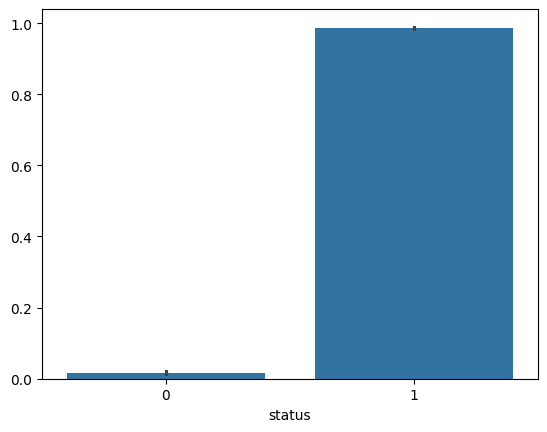

In [30]:
sns.barplot(x=y_test, y=pred_lr)

In [31]:
sample_news = "Breaking: Government announces new education policy."

transformed_news = vectorization.transform([sample_news])
prediction = lr.predict(transformed_news)

if prediction[0] == 0:
    print("This news is Fake")
else:
    print("This news is Real")

This news is Fake


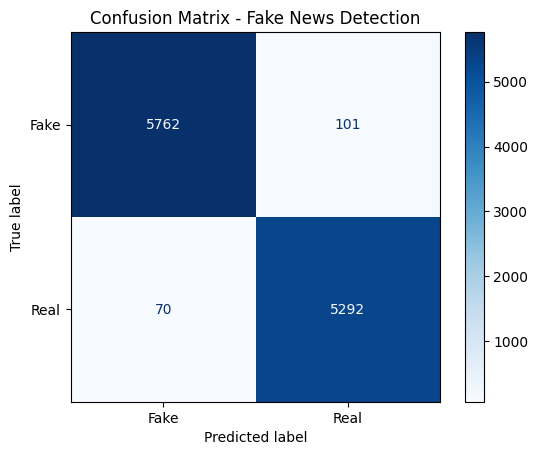

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, pred_lr)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Fake News Detection")
plt.show()